In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import norm
import seaborn as sns
from pathlib import Path

plt.rcParams.update({'font.size': 14})

In [18]:
# Read the aggregated cases data from region-specific models
df = pd.read_csv('data/cases_by_region_month_all_models_by_region.csv', parse_dates=['date_first_symptoms'])

model_ids = {
    'Climate(lag 1-5)': 'C15',
    'Climate(lag 1-5) + Month|region': 'C15-Mr',
    'Climate(lag 1-5) + PriorCases': 'C15-c(PC)',
    'Climate(lag 1-5) + SeroRepla': 'C15-c(SR)',
    'Climate(lag 1-5) + Socio': 'C15-c(S)',
    'Climate(lag 1-5) + Immunity': 'C15-c(IM)',
    'Year + Month': 'Y-M',
    'Year|region + Month|region': 'Yr-Mr',
    'Month|region + PriorCases + SeroRepla + Socio + Immunity': 'Mr-c(PC,SR,S,IM)',
    'Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity': 'C15-c(PC,SR,S,IM)',
    'Year + Month + P(Climate)': 'Y-M-P(C)',
    'Climate(lag 1-5) + Year|region': 'C15-Yr',
    'Climate(lag 1) + Year|region + Month|region': 'C1-Yr-Mr',
    'Climate(lag 1-3) + Year|region + Month|region': 'C13-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region': 'C15-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region + SeroRepla': 'C15-Yr-Mr-c(SR)',
    'Climate(lag 1-5) + Year|region + Month|region + Immunity': 'C15-Yr-Mr-c(IM)',
    'Climate(lag 1-5) + Year|region + Month|region + Socio': 'C15-Yr-Mr-c(S)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases': 'C15-Yr-Mr-c(PC)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity': 'C15-Yr-Mr-c(PC,SR,S,IM)'
}

df['model_id'] = df['model_name'].map(model_ids)

df['region'] = df['region'].replace({'Middle-West': 'Centre-West'})

df

,model_name,region,date_first_symptoms,total_population,total_actual_cases,total_pred_cases,actual_incidence,predicted_incidence,model_id
0,Year|region + Month|region,North,2001-08-01,13546943,1282,714.785974,9.463390,5.276364,Yr-Mr
1,Year|region + Month|region,North,2001-09-01,13546943,1168,773.236165,8.621871,5.707828,Yr-Mr
2,Year|region + Month|region,North,2001-10-01,13546943,1488,926.029150,10.984028,6.835706,Yr-Mr
3,Year|region + Month|region,North,2001-11-01,13546943,2152,1512.526446,15.885503,11.165076,Yr-Mr
4,Year|region + Month|region,North,2001-12-01,13546943,2232,2033.711371,16.476042,15.012327,Yr-Mr
...,...,...,...,...,...,...,...,...,...
26215,Month|region + PriorCases + SeroRepla + Socio ...,South,2024-03-01,29968865,305512,283518.795765,1019.431333,946.044489,"Mr-c(PC,SR,S,IM)"
26216,Month|region + PriorCases + SeroRepla + Socio ...,South,2024-04-01,29968865,372420,349093.872345,1242.689705,1164.855167,"Mr-c(PC,SR,S,IM)"
26217,Month|region + PriorCases + SeroRepla + Socio ...,South,2024-05-01,29968865,239022,220472.986623,797.567742,735.673462,"Mr-c(PC,SR,S,IM)"
26218,Month|region + PriorCases + SeroRepla + Socio ...,South,2024-06-01,29968865,53940,55783.605953,179.986796,186.138534,"Mr-c(PC,SR,S,IM)"


/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_33232/3489870663.py:56: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  xticks = pd.date_range(start='2022-01-01', end=df['date_first_symptoms'].max(), freq='4M')


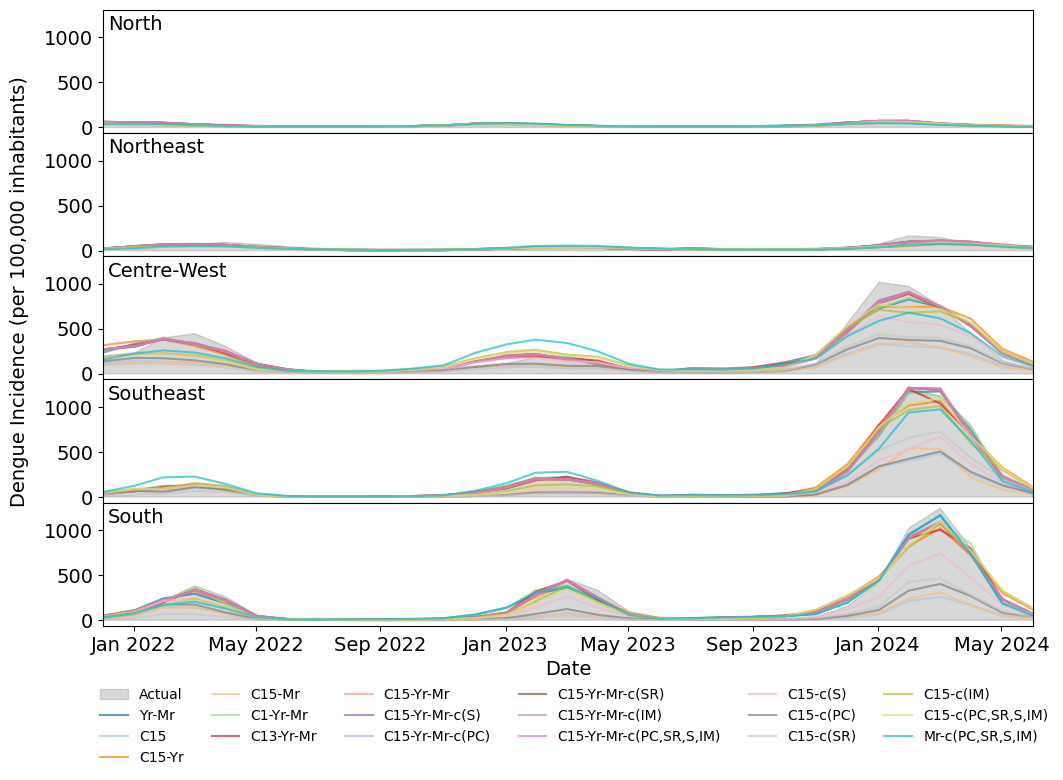


Plot saved as 'model_comparison_by_region_separate_fits.png'


In [96]:
# Create figure with subplots for each region
# Define region order
regions = df['region'].unique()
models = df['model_id'].unique()

region_order = ['North', 'Northeast', 'Centre-West', 'Southeast', 'South']

# Filter to only include regions that exist in the data
regions_to_plot = [r for r in region_order if r in regions]

n_regions = len(regions_to_plot)
n_cols = 1  # 2 columns
n_rows = (n_regions + n_cols - 1) // n_cols  # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0, hspace=0)

axes = axes.flatten() if n_regions > 1 else [axes]

# Define colors for each model - use tab20 to have enough distinct colors
colors = plt.cm.tab20(range(len(models)))
model_colors = dict(zip(models, colors))

# Plot for each region in specified order
for idx, region in enumerate(regions_to_plot):
    ax = axes[idx]
    
    # Filter data for this region
    region_data = df[df['region'] == region].copy()
    
    # Plot actual cases as filled area
    actual_data = region_data[['date_first_symptoms', 'actual_incidence']].drop_duplicates()
    ax.fill_between(actual_data['date_first_symptoms'], 0, actual_data['actual_incidence'], 
                    color='gray', alpha=0.3, label='Actual')
    
    # Plot predicted incidence for each model
    for model in models:
        model_data = region_data[region_data['model_id'] == model]
        if not model_data.empty:
            ax.plot(model_data['date_first_symptoms'], 
                   model_data['predicted_incidence'],
                   linewidth=1.5, label=model, 
                   color=model_colors[model], alpha=0.7)
    
    #ax.set_xlabel('Date', fontsize=11)
    #ax.set_ylabel('Incidence (per 100,000)', fontsize=11)
    # ax.legend(fontsize=8, loc='best')
    #ax.tick_params(axis='x', rotation=45)
    ax.set_xlim([pd.to_datetime('2022-01-01'), df['date_first_symptoms'].max()])
    ax.text(0.005, 0.88, region, transform=ax.transAxes, fontsize=14, va='center', ha='left')

# Remove extra subplots if any
for idx in range(n_regions, len(axes)):
    fig.delaxes(axes[idx])

xticks = pd.date_range(start='2022-01-01', end=df['date_first_symptoms'].max(), freq='4M')

ax.set_xlabel('Date')
ax.text(-0.1, 1, 'Dengue Incidence (per 100,000 inhabitants)', rotation=90, transform=ax.transAxes)
ax.legend(bbox_to_anchor=(1.03, -0.40), frameon=False, fontsize=10, ncols=6)
ax.set_xticks(xticks)
ax.set_xticklabels([x.strftime('%b %Y') for x in xticks])

#plt.tight_layout()
plt.savefig('img/model_comparison_by_region_separate_fits.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPlot saved as 'model_comparison_by_region_separate_fits.png'")

In [58]:
def get_bspline_basis(temp_values, bs_basis_df):
    """
    Get B-spline basis functions for given temperature values
    Uses interpolation from the pre-computed dense grid from R
    """
    basis_funcs = []
    for i in range(1, 5):
        col_name = f'basis{i}'
        interp = interp1d(bs_basis_df['temperature'],
                        bs_basis_df[col_name],
                        kind='cubic',
                        fill_value='extrapolate')
        basis_funcs.append(interp(temp_values))
    
    return np.column_stack(basis_funcs)


def get_bspline_derivative(temp_values, bs_basis_df, delta=0.01):
    """
    Get derivative of B-spline basis functions using finite differences
    """
    basis_x = get_bspline_basis(temp_values, bs_basis_df)
    basis_x_delta = get_bspline_basis(temp_values + delta, bs_basis_df)
    
    return (basis_x_delta - basis_x) / delta


def calculate_response(temp_seq, coefficients, vcov, vcov_rownames, bs_basis_df):
    """
    Calculate response curve with standard errors
    """
    n_temps = len(temp_seq)
    n_lags = 5
    
    bs_basis_vals = get_bspline_basis(temp_seq, bs_basis_df)
    design_mat = np.zeros((n_temps, len(vcov_rownames)))
    coef_idx_map = {name: i for i, name in enumerate(vcov_rownames)}
    
    for lag in range(1, n_lags + 1):
        for basis_i in range(1, 5):
            coef_name = f'temp_bs_lag{lag}{basis_i}'
            if coef_name in coef_idx_map:
                idx = coef_idx_map[coef_name]
                design_mat[:, idx] = bs_basis_vals[:, basis_i - 1]
    
    coef_vec = np.array([coefficients.get(name, 0) for name in vcov_rownames])
    y = design_mat @ coef_vec
    se = np.sqrt(np.sum((design_mat @ vcov) * design_mat, axis=1))
    
    return pd.DataFrame({
        'temperature': temp_seq,
        'response': y,
        'se': se
    })


def calculate_marginal_effect(temp_seq, coefficients, vcov, vcov_rownames, bs_basis_df):
    """
    Calculate delta coef (discrete difference per temperature step) with standard errors
    """
    n_temps = len(temp_seq)
    n_lags = 5
    delta_temp = temp_seq[1] - temp_seq[0]
    bs_deriv = get_bspline_derivative(temp_seq, bs_basis_df) * delta_temp
    design_mat = np.zeros((n_temps, len(vcov_rownames)))
    coef_idx_map = {name: i for i, name in enumerate(vcov_rownames)}
    
    for lag in range(1, n_lags + 1):
        for basis_i in range(1, 5):
            coef_name = f'temp_bs_lag{lag}{basis_i}'
            if coef_name in coef_idx_map:
                idx = coef_idx_map[coef_name]
                design_mat[:, idx] = bs_deriv[:, basis_i - 1]
    
    coef_vec = np.array([coefficients.get(name, 0) for name in vcov_rownames])
    y = design_mat @ coef_vec
    se = np.sqrt(np.sum((design_mat @ vcov) * design_mat, axis=1))
    
    return pd.DataFrame({
        'temperature': temp_seq,
        'marginal_effect': y,
        'se': se
    })

print("Helper functions defined")

Helper functions defined


In [79]:
# Define regions
regions = ['National', 'North', 'Northeast', 'Middle_West', 'Southeast', 'South']
region_labels = ['National', 'North', 'Northeast', 'Middle-West', 'Southeast', 'South']
regional_labels = ['North', 'Northeast', 'Middle-West', 'Southeast', 'South']  # Exclude National

# Storage for region data
region_data = {}

print("Loading data for all regions...\n")

for region, label in zip(regions, region_labels):
    print(f"Loading {label}...")
    
    # Load coefficients
    coef_df = pd.read_csv(f'model_coefficients_{region}.csv')
    coefficients = dict(zip(coef_df['coefficient'], coef_df['value']))
    
    # Load variance-covariance matrix
    vcov_df = pd.read_csv(f'model_vcov_{region}.csv')
    vcov_rownames = vcov_df['row_name'].values
    vcov = vcov_df.drop(['row_name', 'region'], axis=1).values
    
    # Load metadata
    metadata = pd.read_csv(f'model_metadata_{region}.csv')
    metadata_dict = dict(zip(metadata['parameter'], metadata['value']))
    
    # Load B-spline basis
    bs_basis = pd.read_csv(f'bspline_basis_{region}.csv')
    
    # Load temperature data
    temp_data = pd.read_csv(f'temperature_data_{region}.csv')
    
    # Store all data
    region_data[label] = {
        'coefficients': coefficients,
        'vcov': vcov,
        'vcov_rownames': vcov_rownames,
        'metadata': metadata_dict,
        'bs_basis': bs_basis,
        'temp_data': temp_data
    }
    
    print(f"  Temperature range: {metadata_dict['temp_min']:.1f} to {metadata_dict['temp_max']:.1f}°C")
    print(f"  Mean temperature: {metadata_dict['temp_mean']:.1f}°C")
    print(f"  Pseudo R²: {metadata_dict['pseudo_r2']:.4f}\n")

print(f"Loaded data for {len(region_data)} regions (including National)")

Loading data for all regions...

Loading National...
  Temperature range: 7.5 to 33.5°C
  Mean temperature: 23.2°C
  Pseudo R²: 0.7776

Loading North...
  Temperature range: 21.9 to 33.0°C
  Mean temperature: 26.6°C
  Pseudo R²: 0.6175

Loading Northeast...
  Temperature range: 16.3 to 33.5°C
  Mean temperature: 25.9°C
  Pseudo R²: 0.6409

Loading Middle-West...
  Temperature range: 14.6 to 32.2°C
  Mean temperature: 24.0°C
  Pseudo R²: 0.8247

Loading Southeast...
  Temperature range: 12.1 to 31.1°C
  Mean temperature: 21.8°C
  Pseudo R²: 0.8041

Loading South...
  Temperature range: 7.5 to 29.4°C
  Mean temperature: 19.5°C
  Pseudo R²: 0.8004

Loaded data for 6 regions (including National)


In [80]:
print("Calculating temperature responses for all regions...\n")

# Storage for results
all_responses = {}
all_marginals = {}

for label in region_labels:
    print(f"Processing {label}...")
    
    data = region_data[label]
    
    # Define temperature sequence (FULL RANGE: min to max)
    temp_seq = np.linspace(
        data['metadata']['temp_min'],
        data['metadata']['temp_max'],
        200
    )
    # temp_seq = np.linspace(10, 32, 200)
    
    print(f"  Temperature range: {temp_seq.min():.1f} to {temp_seq.max():.1f}°C")
    
    # Calculate response curve
    response_df = calculate_response(
        temp_seq,
        data['coefficients'],
        data['vcov'],
        data['vcov_rownames'],
        data['bs_basis']
    )
    
    # Calculate marginal effect
    marginal_df = calculate_marginal_effect(
        temp_seq,
        data['coefficients'],
        data['vcov'],
        data['vcov_rownames'],
        data['bs_basis']
    )
    
    # Center response at mean temperature
    temp_mean = data['metadata']['temp_mean']
    idx_mean = np.argmin(np.abs(response_df['temperature'] - temp_mean))
    response_df['response_centered'] = response_df['response'] - response_df['response'].iloc[idx_mean]
    
    # Store results
    all_responses[label] = response_df
    all_marginals[label] = marginal_df
    
    print(f"  Response range: {response_df['response_centered'].min():.2f} to {response_df['response_centered'].max():.2f}")
    print(f"  Marginal effect range: {marginal_df['marginal_effect'].min():.3f} to {marginal_df['marginal_effect'].max():.3f}\n")

print("Calculations complete!")

Calculating temperature responses for all regions...

Processing National...
  Temperature range: 7.5 to 33.5°C
  Response range: -8.24 to 12.05
  Marginal effect range: -0.961 to 0.180

Processing North...
  Temperature range: 21.9 to 33.0°C
  Response range: -13.06 to 0.22
  Marginal effect range: -0.466 to 0.127

Processing Northeast...
  Temperature range: 16.3 to 33.5°C
  Response range: -10.85 to 0.09
  Marginal effect range: -0.070 to 0.213

Processing Middle-West...
  Temperature range: 14.6 to 32.2°C
  Response range: -11.81 to 0.00
  Marginal effect range: -0.035 to 0.260

Processing Southeast...
  Temperature range: 12.1 to 31.1°C
  Response range: -5.34 to 3.47
  Marginal effect range: -0.454 to 0.123

Processing South...
  Temperature range: 7.5 to 29.4°C
  Response range: -1.84 to 3.24
  Marginal effect range: -0.189 to 0.071

Calculations complete!


In [86]:
# Calculate temperature where marginal effect crosses zero (i.e., temperature at maximum response)
print("Calculating temperature at maximum response (where marginal effect = 0) for each region...\n")

max_response_data = []

# Process all regions including National
for label in region_labels:
    marginal_df = all_marginals[label]
    
    # Find where marginal effect crosses zero (changes from positive to negative)
    # This is where the response is at its maximum
    
    # Find sign changes
    sign_changes = np.where(np.diff(np.sign(marginal_df['marginal_effect'])))[0]
    
    # We want the crossing from positive to negative (maximum)
    # Find crossings where marginal effect goes from positive to negative
    max_crossing_idx = None
    max_crossing_temp = None
    
    for idx in sign_changes:
        if marginal_df.loc[idx, 'marginal_effect'] > 0 and marginal_df.loc[idx + 1, 'marginal_effect'] < 0:
            # Linear interpolation to find exact zero crossing
            temp1 = marginal_df.loc[idx, 'temperature']
            temp2 = marginal_df.loc[idx + 1, 'temperature']
            me1 = marginal_df.loc[idx, 'marginal_effect']
            me2 = marginal_df.loc[idx + 1, 'marginal_effect']
            
            # Interpolate: temp = temp1 - me1 * (temp2 - temp1) / (me2 - me1)
            temp_at_zero = temp1 - me1 * (temp2 - temp1) / (me2 - me1)
            
            max_crossing_idx = idx
            max_crossing_temp = temp_at_zero
            break  # Take the first positive-to-negative crossing (the maximum)
    
    if max_crossing_temp is None:
        print(f"{label}: No zero crossing found (marginal effect doesn't change sign)")
        continue
    
    # Calculate confidence interval using delta method
    # At the zero crossing, we need to propagate uncertainty from the marginal effect curve
    # Use the standard errors at the crossing points
    se1 = marginal_df.loc[max_crossing_idx, 'se']
    se2 = marginal_df.loc[max_crossing_idx + 1, 'se']
    
    # Average SE at the crossing
    se_at_crossing = (se1 + se2) / 2
    
    # Calculate temperature uncertainty using the slope of the marginal effect at crossing
    # Delta method: SE(temp) ≈ SE(ME) / |slope of ME|
    temp1 = marginal_df.loc[max_crossing_idx, 'temperature']
    temp2 = marginal_df.loc[max_crossing_idx + 1, 'temperature']
    me1 = marginal_df.loc[max_crossing_idx, 'marginal_effect']
    me2 = marginal_df.loc[max_crossing_idx + 1, 'marginal_effect']
    
    # Slope of marginal effect at crossing
    slope = (me2 - me1) / (temp2 - temp1)
    
    if abs(slope) > 1e-6:  # Avoid division by very small numbers
        # Standard error of temperature at zero crossing
        se_temp = se_at_crossing / abs(slope)
        
        # 95% confidence interval
        temp_ci_lower = max_crossing_temp - 1.96 * se_temp
        temp_ci_upper = max_crossing_temp + 1.96 * se_temp
    else:
        # If slope is nearly zero, use a small default interval
        temp_ci_lower = max_crossing_temp - 1
        temp_ci_upper = max_crossing_temp + 1
    
    max_response_data.append({
        'region': label,
        'temp_at_max': max_crossing_temp,
        'temp_ci_lower': temp_ci_lower,
        'temp_ci_upper': temp_ci_upper,
        'se_temp': se_temp if abs(slope) > 1e-6 else np.nan
    })
    
    print(f"{label}: {max_crossing_temp:.1f}°C (95% CI: [{temp_ci_lower:.1f}, {temp_ci_upper:.1f}])")

max_response_df = pd.DataFrame(max_response_data)

print(max_response_df)

Calculating temperature at maximum response (where marginal effect = 0) for each region...

National: 24.0°C (95% CI: [23.5, 24.6])
North: 25.1°C (95% CI: [23.8, 26.4])
Northeast: 27.1°C (95% CI: [26.3, 27.9])
Middle-West: 24.0°C (95% CI: [22.9, 25.2])
Southeast: 24.7°C (95% CI: [24.3, 25.1])
South: 25.0°C (95% CI: [24.4, 25.7])
        region  temp_at_max  temp_ci_lower  temp_ci_upper   se_temp
0     National    24.048245      23.534263      24.562227  0.262236
1        North    25.099345      23.825360      26.373330  0.649992
2    Northeast    27.101151      26.284225      27.918077  0.416799
3  Middle-West    24.049594      22.878959      25.220229  0.597263
4    Southeast    24.700799      24.265380      25.136219  0.222153
5        South    25.036598      24.378963      25.694234  0.335528



Marginal effects plot saved as marginal_effects_by_region.pdf


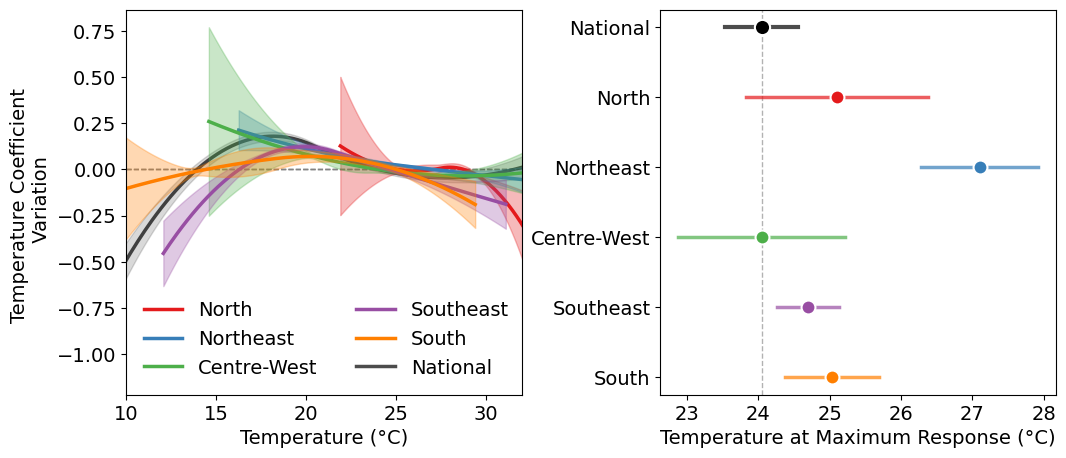

In [95]:
# Define colors for each region
colors = {
    'North': '#e41a1c',
    'Northeast': '#377eb8',
    'Middle-West': '#4daf4a',
    'Southeast': '#984ea3',
    'South': '#ff7f00'
}

# Create a single figure with 5 subplots for marginal effects
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'wspace': 0.35})

# Get national marginal effect data
national_marginal = all_marginals['National']

for i, label in enumerate(regional_labels):
    data = region_data[label]
    marginal_df = all_marginals[label]
    
    
    # Plot REGIONAL marginal effect (foreground)
    ax1.plot(marginal_df['temperature'], marginal_df['marginal_effect'],
           color=colors[label], linewidth=2.5, label=label if label != 'Middle-West' else 'Centre-West', zorder=2)
    
    # Plot regional confidence interval
    ci_lower = marginal_df['marginal_effect'] + norm.ppf(0.025) * marginal_df['se']
    ci_upper = marginal_df['marginal_effect'] + norm.ppf(0.975) * marginal_df['se']
    ax1.fill_between(marginal_df['temperature'], ci_lower, ci_upper,
                   alpha=0.3, color=colors[label], zorder=2)
    
    # Add reference line at zero
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1, zorder=0)
  
    # Set x-axis limits to match the region's temperature range
    ax1.set_xlim(10, 32)
    # ax.set_ylim(-10, 5)

    ax1.set_xlabel('Temperature (°C)')
    ax1.set_ylabel('Temperature Coefficient \n Variation')


# Plot NATIONAL marginal effect in BLACK (same curve on all subplots)
ax1.plot(national_marginal['temperature'], national_marginal['marginal_effect'],
        color='black', linewidth=2.5, alpha=0.7, label='National', zorder=1)

# Plot national confidence interval
ci_lower_nat = national_marginal['marginal_effect'] + norm.ppf(0.025) * national_marginal['se']
ci_upper_nat = national_marginal['marginal_effect'] + norm.ppf(0.975) * national_marginal['se']
ax1.fill_between(national_marginal['temperature'], ci_lower_nat, ci_upper_nat, alpha=0.15, color='black', zorder=1)
ax1.legend(frameon=False, ncols=2)

# Reorder for plotting (National at top, then regions from North to South)
plot_order = [
    'National',
    'North',
    'Northeast', 
    'Middle-West', 
    'Southeast', 
    'South',
]
# Only include regions that have data
plot_order = [r for r in plot_order if r in max_response_df['region'].values]
y_positions = {region: i for i, region in enumerate(reversed(plot_order))}

for _, row in max_response_df.iterrows():
    region = row['region']
    y_pos = y_positions[region]
    
    # Determine color
    if region == 'National':
        color = 'black'
        marker_size = 120
        linewidth = 3
    else:
        color = colors[region.split('_')[0] if region.endswith('_nofixed') else region]
        marker_size = 100
        linewidth = 2.5
    
    # Plot confidence interval as horizontal line
    ax2.plot([row['temp_ci_lower'], row['temp_ci_upper']], 
           [y_pos, y_pos],
           color=color, linewidth=linewidth, alpha=0.7, zorder=1)
    
    # Plot point estimate
    ax2.scatter(row['temp_at_max'], y_pos, 
              color=color, s=marker_size, zorder=2, edgecolor='white', linewidth=1.5)

# Formatting
y_positions["Centre-West"] = y_positions.pop("Middle-West")  # Rename for display

ax2.set_yticks(list(y_positions.values()))
ax2.set_yticklabels(list(y_positions.keys()))
ax2.set_xlabel('Temperature at Maximum Response (°C)')
#ax2.set_ylabel('Region')


# Add vertical line at national estimate for reference
if 'National' in max_response_df['region'].values:
    national_temp = max_response_df[max_response_df['region'] == 'National']['temp_at_max'].values[0]
    ax2.axvline(x=national_temp, color='black', linestyle='--', alpha=0.3, linewidth=1, zorder=0)

#ax.legend()
#plt.tight_layout()
plt.savefig('img/marginal_effects_by_region.pdf', dpi=300, bbox_inches='tight')
print("\nMarginal effects plot saved as marginal_effects_by_region.pdf")
plt.show()